In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
pos = pd.read_csv("pos.csv")

In [3]:
pos

,chan_name,x,y,z,dist
0,0-0,0.0002,2.5497,0.0007,2.549700
1,0-1,0.0002,2.5497,0.0007,2.549700
2,0-2,2.2499,1.3497,0.0002,2.623688
3,0-3,2.2499,1.3497,0.0002,2.623688
4,0-4,2.2503,-1.3499,0.0000,2.624134
...,...,...,...,...,...
519,5-81,67.2167,38.7385,0.0059,77.580643
520,5-82,66.7875,42.6992,0.0069,79.270372
521,5-83,66.7875,42.6992,0.0069,79.270372
522,5-84,67.1713,48.1707,0.0077,82.658332


In [4]:
dur = 100
covs = np.load(f"results/Covs/{100}/all_covs.npy")

In [5]:
covs

array([[[ 2.21956823e-08, -5.06779896e-09, -1.81541503e-08, ...,
          9.97226738e-10, -2.82885065e-10, -9.12323224e-10],
        [-5.06779896e-09,  2.11276567e-08, -5.71098820e-09, ...,
          6.23371275e-10, -7.03214576e-10, -3.24550874e-10],
        [-1.81541503e-08, -5.71098820e-09,  2.24929744e-08, ...,
         -1.55419019e-09,  5.62063323e-10,  1.23414178e-09],
        ...,
        [ 9.97226738e-10,  6.23371275e-10, -1.55419019e-09, ...,
          2.22645004e-08, -4.74018158e-09, -1.81879712e-08],
        [-2.82885065e-10, -7.03214576e-10,  5.62063323e-10, ...,
         -4.74018158e-09,  2.14929141e-08, -5.41769003e-09],
        [-9.12323224e-10, -3.24550874e-10,  1.23414178e-09, ...,
         -1.81879712e-08, -5.41769003e-09,  2.20320010e-08]],

       [[ 2.21437031e-08, -4.85113218e-09, -1.77282228e-08, ...,
          2.35424563e-09, -7.21635954e-10, -2.56852240e-09],
        [-4.85113218e-09,  2.20180504e-08, -6.69849376e-09, ...,
         -1.49988091e-10,  2.88011584e

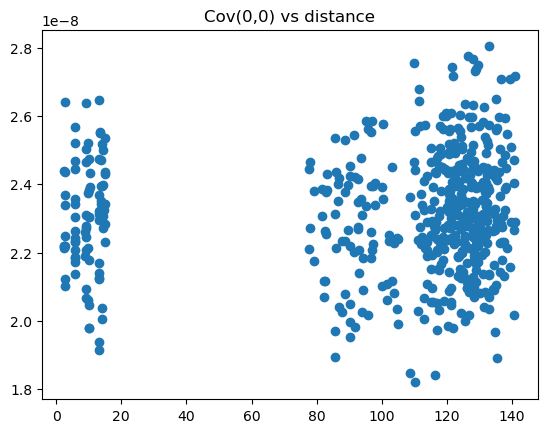

In [6]:
plt.figure()
plt.scatter(pos.dist, covs[:, 0,0])
plt.title("Cov(0,0) vs distance")
plt.show()

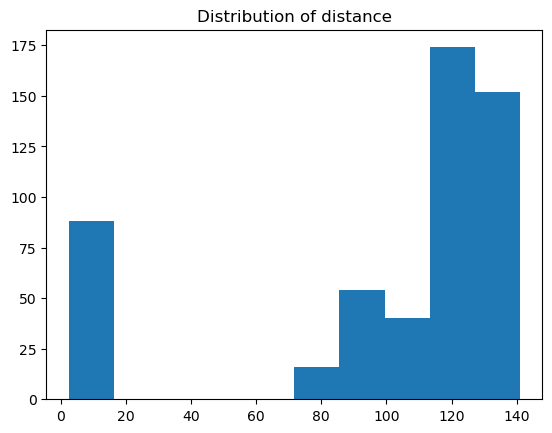

In [7]:
plt.hist(pos.dist)
plt.title("Distribution of distance")
plt.show()

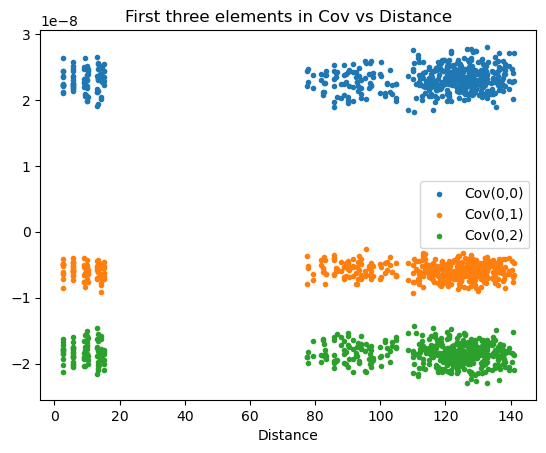

In [8]:
plt.figure()
plt.scatter(pos.dist, covs[:, 0,0], label="Cov(0,0)", marker=".")
plt.scatter(pos.dist, covs[:, 0,1], label="Cov(0,1)", marker=".")
plt.scatter(pos.dist, covs[:, 0,2], label="Cov(0,2)", marker=".")
plt.legend()
plt.xlabel("Distance")
plt.title("First three elements in Cov vs Distance")
plt.show()

In [32]:
covs.shape[1]

100

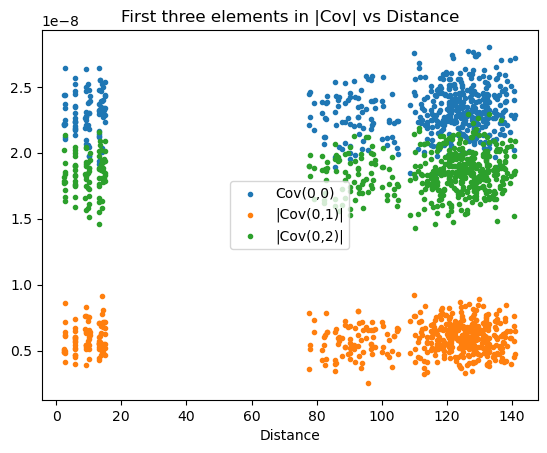

In [33]:
plt.figure()
plt.scatter(pos.dist, np.abs(covs[:, 0,0]), label="Cov(0,0)", marker=".")
plt.scatter(pos.dist, np.abs(covs[:, 0,1]), label="|Cov(0,1)|", marker=".")
plt.scatter(pos.dist, np.abs(covs[:, 0,2]), label="|Cov(0,2)|", marker=".")
plt.legend()
plt.xlabel("Distance")
plt.title("First three elements in |Cov| vs Distance")
plt.savefig(f"results/Covs/{covs.shape[1]}/3entry.pdf", format="pdf")
plt.show()

In [11]:
pos.insert(pos.columns.get_loc("chan_name")+1, "stn_name", pos.chan_name.str[0])

In [12]:
pos.stn_name = pos.stn_name.astype(int)

In [13]:
pos.insert(len(pos.columns), "(0,0)", covs[:,0,0])

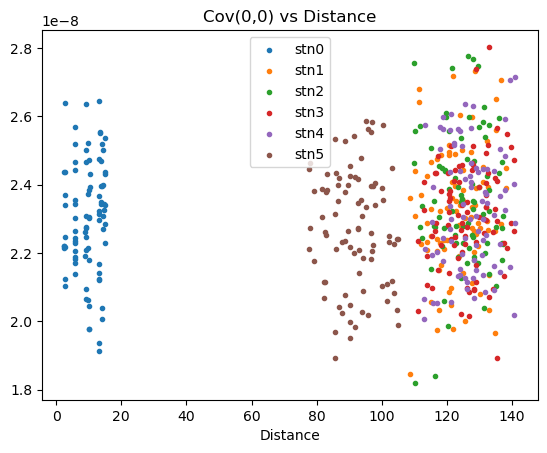

In [34]:
plt.figure()
for i in range(6):
    plt.scatter(pos[pos.stn_name == i].dist, pos[pos.stn_name==i]["(0,0)"], label=f"stn{i}", marker=".")
    
plt.legend()
plt.xlabel("Distance")
plt.title("Cov(0,0) vs Distance")
plt.savefig(f"results/Covs/{covs.shape[1]}/Cov00.pdf", format="pdf")
plt.show()

In [15]:
pos

,chan_name,stn_name,x,y,z,dist,"(0,0)"
0,0-0,0,0.0002,2.5497,0.0007,2.549700,2.219568e-08
1,0-1,0,0.0002,2.5497,0.0007,2.549700,2.214370e-08
2,0-2,0,2.2499,1.3497,0.0002,2.623688,2.436021e-08
3,0-3,0,2.2499,1.3497,0.0002,2.623688,2.368576e-08
4,0-4,0,2.2503,-1.3499,0.0000,2.624134,2.247218e-08
...,...,...,...,...,...,...,...
519,5-81,5,67.2167,38.7385,0.0059,77.580643,2.445321e-08
520,5-82,5,66.7875,42.6992,0.0069,79.270372,2.176098e-08
521,5-83,5,66.7875,42.6992,0.0069,79.270372,2.380662e-08
522,5-84,5,67.1713,48.1707,0.0077,82.658332,2.262396e-08


In [16]:
pos.insert(len(pos.columns), "cov", list(covs))

In [17]:
pos.loc[0, "cov"]

array([[ 2.21956823e-08, -5.06779896e-09, -1.81541503e-08, ...,
         9.97226738e-10, -2.82885065e-10, -9.12323224e-10],
       [-5.06779896e-09,  2.11276567e-08, -5.71098820e-09, ...,
         6.23371275e-10, -7.03214576e-10, -3.24550874e-10],
       [-1.81541503e-08, -5.71098820e-09,  2.24929744e-08, ...,
        -1.55419019e-09,  5.62063323e-10,  1.23414178e-09],
       ...,
       [ 9.97226738e-10,  6.23371275e-10, -1.55419019e-09, ...,
         2.22645004e-08, -4.74018158e-09, -1.81879712e-08],
       [-2.82885065e-10, -7.03214576e-10,  5.62063323e-10, ...,
        -4.74018158e-09,  2.14929141e-08, -5.41769003e-09],
       [-9.12323224e-10, -3.24550874e-10,  1.23414178e-09, ...,
        -1.81879712e-08, -5.41769003e-09,  2.20320010e-08]],
      shape=(100, 100))

In [18]:
pos_sort = pos.sort_values(by = "dist").reset_index()

In [19]:
pos_sort

,index,chan_name,stn_name,x,y,z,dist,"(0,0)",cov
0,0,0-0,0,0.0002,2.5497,0.0007,2.549700,2.219568e-08,"[[2.219568226340531e-08, -5.067798962902603e-0..."
1,1,0-1,0,0.0002,2.5497,0.0007,2.549700,2.214370e-08,"[[2.2143703082731466e-08, -4.851132179902062e-..."
2,7,0-7,0,-0.0003,-2.5497,-0.0007,2.549700,2.437389e-08,"[[2.4373891915490152e-08, -5.134878523736215e-..."
3,6,0-6,0,-0.0003,-2.5497,-0.0007,2.549700,2.219615e-08,"[[2.219614635661745e-08, -4.8505780334114845e-..."
4,2,0-2,0,2.2499,1.3497,0.0002,2.623688,2.436021e-08,"[[2.436020810054447e-08, -8.580768755436943e-0..."
...,...,...,...,...,...,...,...,...,...
519,349,3-87,3,37.5876,-135.4020,-0.0125,140.522344,2.471912e-08,"[[2.471912303262996e-08, -5.7560562061932494e-..."
520,408,4-58,4,132.3333,-47.5659,0.0001,140.622250,2.402997e-08,"[[2.402996997367271e-08, -7.593324069659334e-0..."
521,409,4-59,4,132.3333,-47.5659,0.0001,140.622250,2.017948e-08,"[[2.0179475326518566e-08, -6.82153043047297e-0..."
522,406,4-56,4,133.6597,-44.7364,0.0012,140.947724,2.716248e-08,"[[2.716247733063253e-08, -6.491827810255984e-0..."


/tmp/ipykernel_7208/1396179159.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x, pos_sort.loc[interval*j, "cov"][0, :ent], marker=".", c=color)


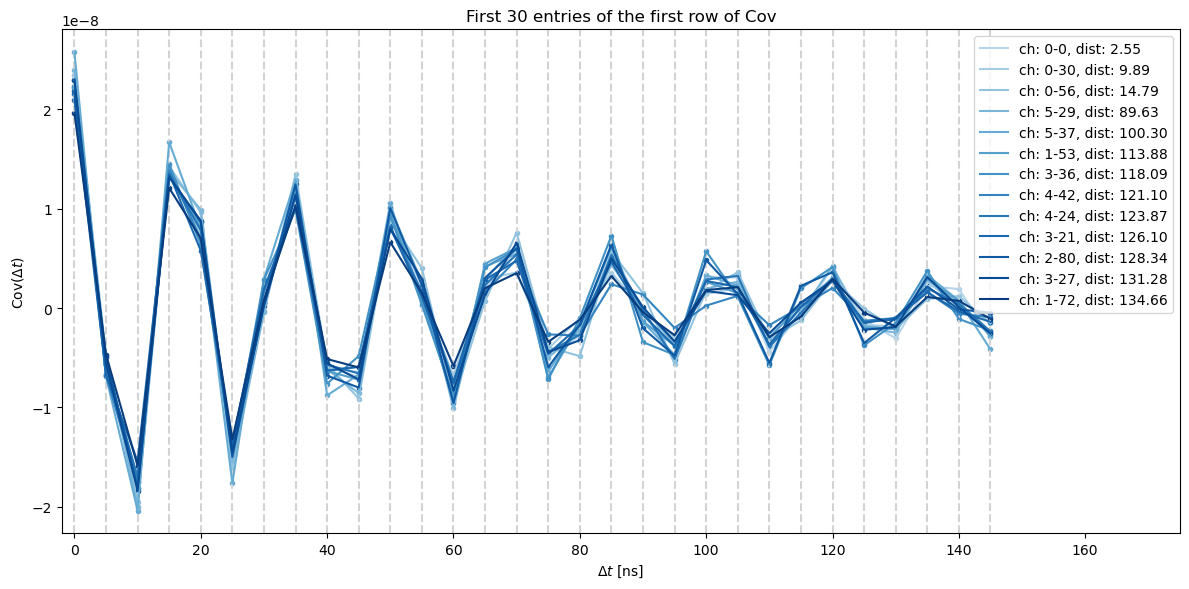

In [35]:
ent = 30
interval = 40

x = np.arange(ent)*5
totn = len(pos)//interval
cmap = plt.cm.Blues

plt.figure(figsize=(12,6))

for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for j in range(totn):
    color = cmap(0.3+0.7*j/totn)
    plt.plot(x, pos_sort.loc[interval*j, "cov"][0, :ent], label="ch: "+pos_sort.loc[interval*j, "chan_name"]+f", dist: {pos_sort.loc[interval*j, "dist"]:.2f}", c=color)
    plt.scatter(x, pos_sort.loc[interval*j, "cov"][0, :ent], marker=".", c=color)

plt.title(f"First {ent} entries of the first row of Cov")
plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Cov($\Delta t$)")
plt.legend()
plt.tight_layout()
plt.xlim(-2, x[-1]+ent)
plt.savefig(f"results/Covs/{covs.shape[1]}/dist_comp_int{interval}.pdf", format="pdf")
plt.show()

/tmp/ipykernel_7208/1175307182.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x, pos_sort.loc[interval*j, "cov"][0, :ent], marker=".", c=color)


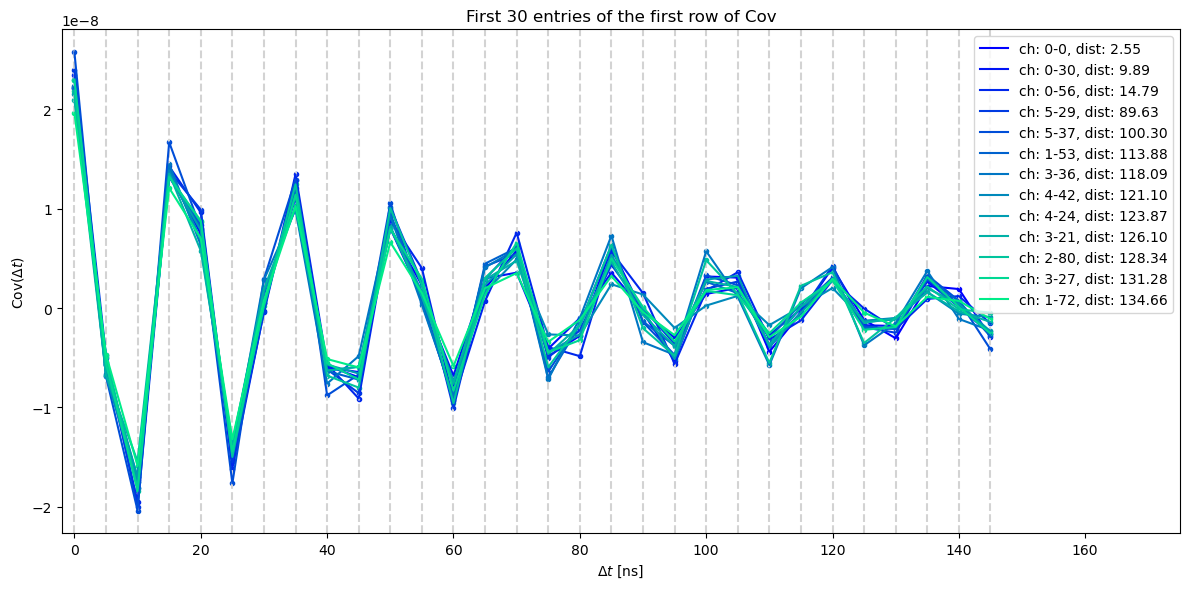

In [30]:
ent = 30
interval = 40

x = np.arange(ent)*5
totn = len(pos)//interval
cmap = plt.cm.winter

plt.figure(figsize=(12,6))

for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for j in range(totn):
    color = cmap(j/totn)
    plt.plot(x, pos_sort.loc[interval*j, "cov"][0, :ent], label="ch: "+pos_sort.loc[interval*j, "chan_name"]+f", dist: {pos_sort.loc[interval*j, "dist"]:.2f}", c=color)
    plt.scatter(x, pos_sort.loc[interval*j, "cov"][0, :ent], marker=".", c=color)

plt.title(f"First {ent} entries of the first row of Cov")
plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Cov($\Delta t$)")
plt.legend()
plt.tight_layout()
plt.xlim(-2, x[-1]+ent)
plt.show()